# **Automated Grading and Feedback**
**Abstract**

The Automated Essay and Assignment Scoring System enhances the evaluation process by leveraging Natural Language Processing (NLP) and Machine Learning to assess typed submissions with speed, accuracy, and fairness. The system evaluates assignments based on key rubric criteria such as content relevance, grammar, structure, coherence, and originality, ensuring objective and consistent grading.

The framework comprises text preprocessing , feature extraction, and assessment through multiple machine learning and Deep learning models. By automating the grading process, it significantly reduces educators' workload, minimizes subjectivity, and provides students with detailed, data-driven feedback to support academic growth. Additionally, by analyzing large volumes of text, the system enhances assessment transparency and facilitates a more efficient and scalable evaluation process, making grading smarter, faster, and more reliable in the digital age.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is i

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd
import torch

# Loading Dataset

In [ ]:
data = pd.read_csv('/content/EssayScoringDataset.csv')


# Text Preprocessing


In [ ]:
import re
cList = {
  "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have","couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hadn't've": "had not have","hasn't": "has not",
  "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
  "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will","I'll've": "I will have","I'm": "I am","I've": "I have",
  "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us","ma'am": "madam","mayn't": "may not",
  "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not","mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not","oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
  "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
  "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would","that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is","they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are","they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
  "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
  "weren't": "were not","what'll": "what will","what'll've": "what will have",
  "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
  "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is","who've": "who have","why's": "why is",
  "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
  "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
  "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have","you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"
   }

c_re = re.compile('(%s)' % '|'.join(cList.keys()))

def expandContractions(text, c_re=c_re):
    def replace(match):
        return cList[match.group(0)]
    return c_re.sub(replace, text)

def removeHTML(x):
    html=re.compile(r'<.*?>')
    return html.sub(r'',x)

def dataPreprocessing(x):
    x = x.lower()
    x = removeHTML(x)
    x = re.sub("@\w+", '',x)
    x = re.sub("'\d+", '',x)
    x = re.sub("\d+", '',x)
    x = re.sub("http\w+", '',x)
    x = re.sub(r"\s+", " ", x)
    x = expandContractions(x)
    x = re.sub(r"\.+", ".", x)
    x = re.sub(r"\,+", ",", x)
    x = re.sub(r'[^a-z\s]', '', x)  # Keeps only alphabetic characters and spaces

    return x


In [ ]:
data['text'].apply(dataPreprocessing)
data['score'].astype
dataset = Dataset.from_pandas(data[['text', 'score']])

dataset = dataset.shuffle(seed=42)



---



**Model Training**

# **DEBerta-V3**

DeBERTa improves the BERT and RoBERTa models using disentangled attention and enhanced mask decoder. With those two improvements, DeBERTa out perform RoBERTa on a majority of NLU tasks with 80GB training data.

In DeBERTa V3, we further improved the efficiency of DeBERTa using ELECTRA-Style pre-training with Gradient Disentangled Embedding Sharing. Compared to DeBERTa, our V3 version significantly improves the model performance on downstream tasks.


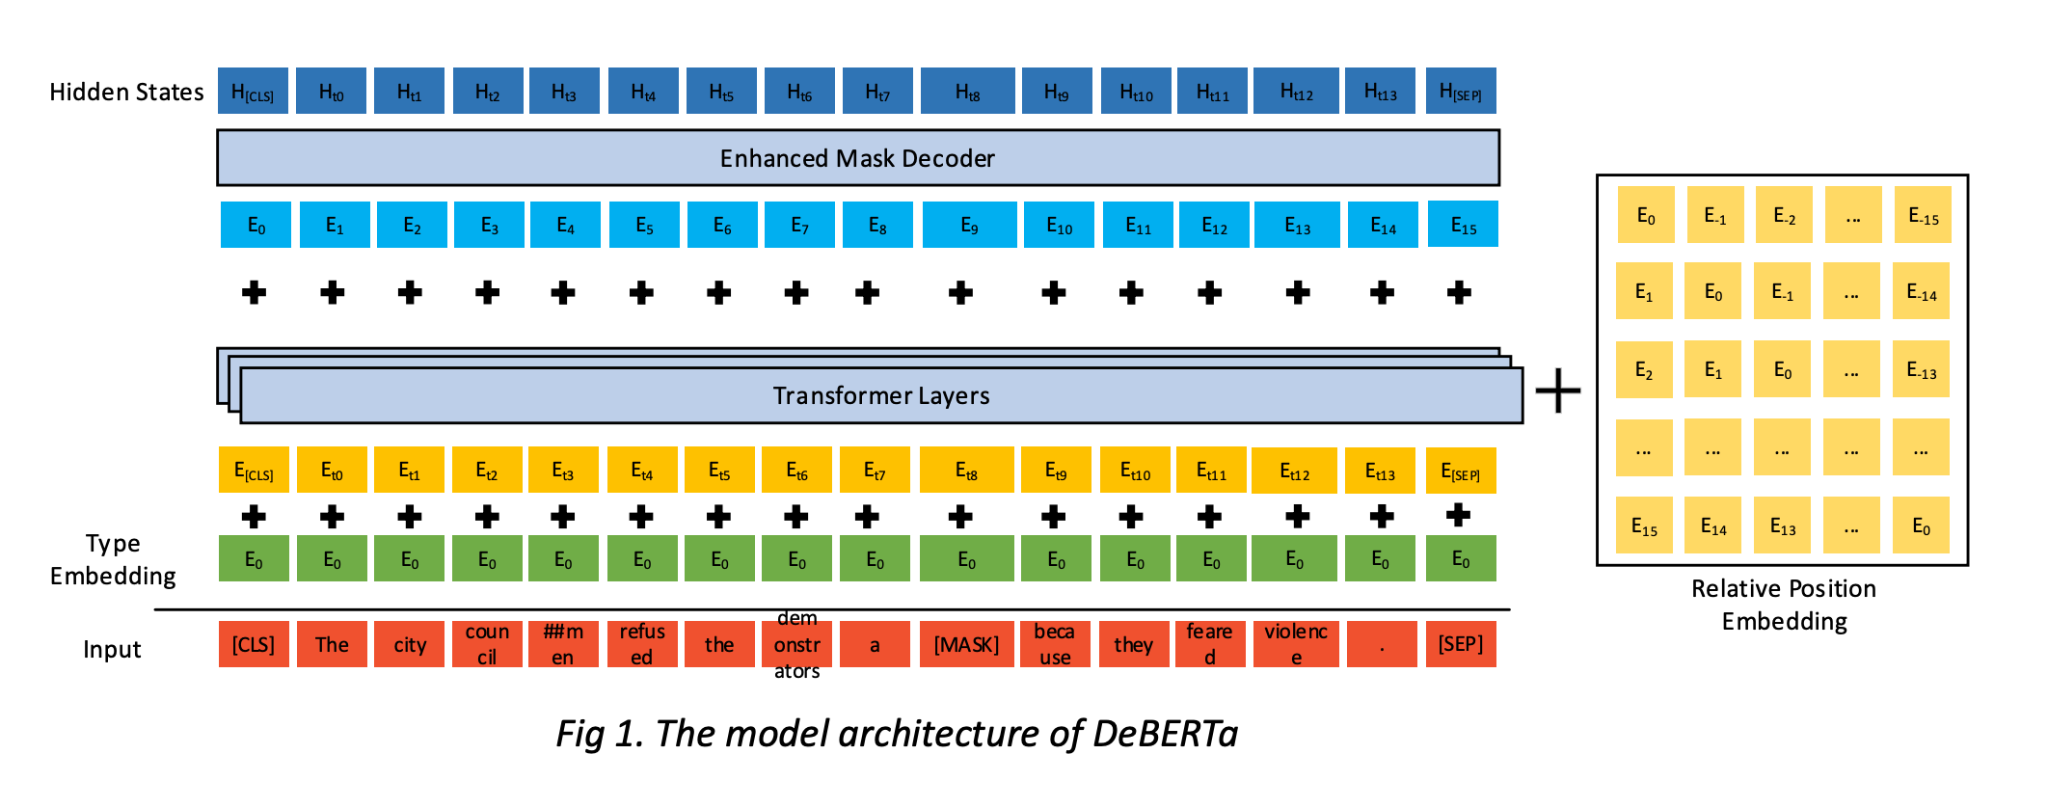

Text Embedding using BERT

In [ ]:
model_name = 'microsoft/deberta-v3-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset
def tokenize_function(examples):

    examples['labels'] = list(map(float, examples['score']))
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=160)

tokenized_dataset = dataset.map(tokenize_function, batched=True, num_proc=12)

tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
train_test_split = tokenized_dataset.train_test_split(test_size=0.025)
train_dataset = train_test_split['train']
val_dataset = train_test_split['test']

Map (num_proc=12):   0%|          | 0/4711 [00:00<?, ? examples/s]

Model Hyperparameters

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.25e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=6,
    num_train_epochs=30,
    weight_decay=1e-3,
    logging_dir="./logs",
    logging_steps=32,
    save_total_limit=1,
    load_best_model_at_end=True,
    fp16=True,
    warmup_steps=256,
)




/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Training Model

In [ ]:
from sklearn.metrics import r2_score, cohen_kappa_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.squeeze(predictions)
    r2 = r2_score(labels, predictions)
    pred_rounded = np.round(predictions).astype(int)
    labels = labels.astype(int)

    qwk = cohen_kappa_score(labels, pred_rounded, weights="quadratic")

    return {"r2": r2, "qwk": qwk}
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


<ipython-input-9-94f443b378ed>:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: yashmah22comp (majorproject2024) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,R2,Qwk
1,No log,36.651627,-3.851671,0.000000
2,34.574700,35.455421,-3.693325,0.000000
3,33.414100,28.848833,-2.818794,0.000000
4,22.956000,12.980392,-0.718247,0.053463
5,22.956000,6.006865,0.204856,0.286934
6,9.547900,3.596169,0.523966,0.694034
7,4.487700,3.563299,0.528317,0.745553
8,3.136600,2.568626,0.659985,0.811931
9,3.136600,2.597534,0.656158,0.820800
10,2.606500,2.730553,0.638550,0.794734


TrainOutput(global_step=720, training_loss=5.961474770969815, metrics={'train_runtime': 2811.7954, 'train_samples_per_second': 49.004, 'train_steps_per_second': 0.256, 'total_flos': 1.13294990569248e+16, 'train_loss': 5.961474770969815, 'epoch': 30.0})

Evaluation of Model

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results : {eval_results}")
print(f"R-squared (R2) Score: {eval_results['eval_r2']}")
print(f"Quadratic Weighted Kappa (QWK) Score: {eval_results['eval_qwk']}")
trainer.save_model("./fine-tuned-deberta-v3-regression")
tokenizer.save_pretrained("./fine-tuned-deberta-v3-regression")

Evaluation results : {'eval_loss': 2.0680902004241943, 'eval_r2': 0.7811997532844543, 'eval_qwk': 0.8767486283275757, 'eval_runtime': 0.5279, 'eval_samples_per_second': 223.517, 'eval_steps_per_second': 7.577, 'epoch': 30.0}
R-squared (R2) Score: 0.7811997532844543
Quadratic Weighted Kappa (QWK) Score: 0.8767486283275757


('./fine-tuned-deberta-v3-regression/tokenizer_config.json',
 './fine-tuned-deberta-v3-regression/special_tokens_map.json',
 './fine-tuned-deberta-v3-regression/spm.model',
 './fine-tuned-deberta-v3-regression/added_tokens.json',
 './fine-tuned-deberta-v3-regression/tokenizer.json')



---





# BERT Model

BERT (Bidirectional Encoder Representations from Transformers) stands as an open-source machine learning framework designed for the natural language processing (NLP). Originating in 2018, this framework was crafted by researchers from Google AI Language.


BERT (Bidirectional Encoder Representations from Transformers) leverages a transformer-based neural network to understand and generate human-like language. BERT employs an encoder-only architecture. In the original Transformer architecture, there are both encoder and decoder modules. The decision to use an encoder-only architecture in BERT suggests a primary emphasis on understanding input sequences rather than generating output sequences.

BERT addresses this challenge with two innovative training strategies:

1. Masked Language Model (MLM)
2. Next Sentence Prediction (NSP)


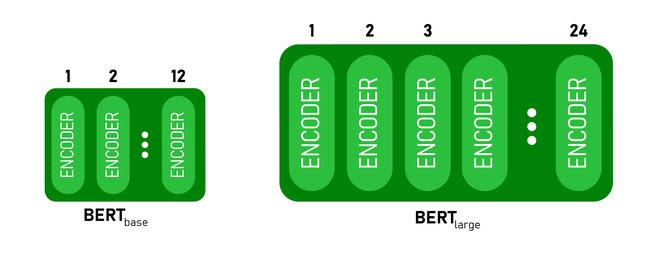

Text Embedding using Bert

In [ ]:
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=1)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from datasets import Dataset
def tokenize_function(examples):

    examples['labels'] = list(map(float, examples['score']))
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=160)

tokenized_dataset = dataset.map(tokenize_function, batched=True, num_proc=12)

tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
train_test_split = tokenized_dataset.train_test_split(test_size=0.025)
train_dataset = train_test_split['train']




Map (num_proc=12):   0%|          | 0/4711 [00:00<?, ? examples/s]

Model Hyperparameter

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=30,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    fp16=True
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from sklearn.metrics import r2_score, cohen_kappa_score
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.squeeze(predictions)
    r2 = r2_score(labels, predictions)
    pred_rounded = np.round(predictions).astype(int)
    labels = labels.astype(int)
    qwk = cohen_kappa_score(labels, pred_rounded, weights="quadratic")
    return {"r2": r2, "qwk": qwk}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


<ipython-input-18-e86e678a4b6b>:13: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,R2,Qwk
1,11.377800,2.501100,0.729428,0.831221
2,2.977900,1.808779,0.804324,0.874670
3,2.018000,1.839984,0.800948,0.881791
4,1.748000,1.379459,0.850769,0.918016
5,1.119600,0.617442,0.933204,0.960583
6,0.816800,0.544515,0.941094,0.966312
7,0.596500,0.390855,0.957717,0.975884
8,0.455300,0.285537,0.969110,0.982955
9,0.376700,0.391085,0.957692,0.973652
10,0.310400,0.262148,0.971641,0.982771


TrainOutput(global_step=4320, training_loss=0.7161764687410107, metrics={'train_runtime': 1433.0165, 'train_samples_per_second': 96.154, 'train_steps_per_second': 3.015, 'total_flos': 1.13292958773024e+16, 'train_loss': 0.7161764687410107, 'epoch': 30.0})

Evaluation of Result

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation results : {eval_results}")
print(f"R-squared (R2) Score: {eval_results['eval_r2']}")
print(f"Quadratic Weighted Kappa (QWK) Score: {eval_results['eval_qwk']}")

Evaluation results : {'eval_loss': 0.12202785909175873, 'eval_r2': 0.986798882484436, 'eval_qwk': 0.99354293167792, 'eval_runtime': 2.071, 'eval_samples_per_second': 455.341, 'eval_steps_per_second': 14.486, 'epoch': 30.0}
R-squared (R2) Score: 0.986798882484436
Quadratic Weighted Kappa (QWK) Score: 0.99354293167792


Saving Model

In [ ]:
trainer.save_model("./fine-tuned-bert-essay")
tokenizer.save_pretrained("./fine-tuned-bert-essay")

('./fine-tuned-bert-essay/tokenizer_config.json',
 './fine-tuned-bert-essay/special_tokens_map.json',
 './fine-tuned-bert-essay/vocab.txt',
 './fine-tuned-bert-essay/added_tokens.json',
 './fine-tuned-bert-essay/tokenizer.json')



---



# **Model Results:**


        Model  R² Score  QWK Score
0  DEBerta-V3    0.7812     0.8767
1        Bert    0.9868     0.9935


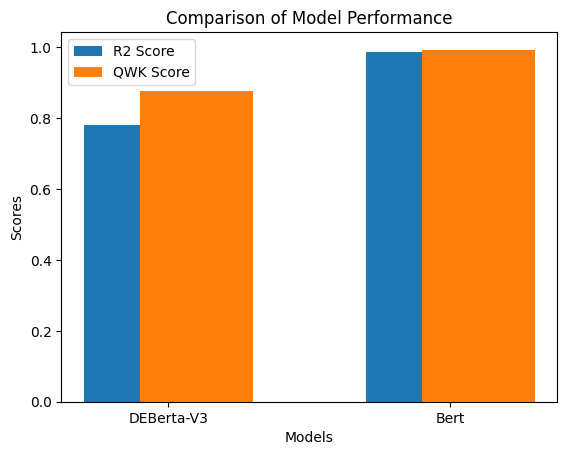

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
def plot_comparison():
    models = ["DEBerta-V3", "Bert"]
    r2_scores = [0.7812, 0.9868]
    qwk_scores = [0.8767, 0.9935]
    df2 = pd.DataFrame({"Model": models, "R² Score": r2_scores, "QWK Score": qwk_scores})
    print(df2)
    x = np.arange(len(models))
    width = 0.4
    fig, ax = plt.subplots()
    bars1 = ax.bar(x - width/4, r2_scores, width, label='R2 Score')
    bars2 = ax.bar(x + width/4, qwk_scores, width, label='QWK Score')

    ax.set_xlabel('Models')
    ax.set_ylabel('Scores')
    ax.set_title('Comparison of Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    plt.show()
plot_comparison()


# **Testing on Real Word Input**

Bert Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "./fine-tuned-bert-essay"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

def predict_essay_score(essay):
    inputs = tokenizer(essay, padding="max_length", truncation=True, max_length=160, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        score = outputs.logits.item()
    return round(score, 2)


user_essay = input("Enter your essay: ")
predicted_score = predict_essay_score(user_essay)
print(f"Predicted Essay Score: {predicted_score}")


Enter your essay: Education is the foundation of a prosperous and progressive society. It plays a crucial role in shaping individuals and equipping them with the necessary skills to navigate an increasingly complex world. From fostering critical thinking to promoting innovation, education remains one of the most powerful tools for personal and collective advancement.  One of the most significant benefits of education is its ability to break the cycle of poverty. A well-educated population has greater access to employment opportunities, leading to improved living standards and economic growth. Additionally, education enhances an individual's decision-making ability, allowing them to contribute meaningfully to society.  Furthermore, education is a catalyst for social change. It promotes equality by providing individuals from diverse backgrounds with the same opportunities to succeed. Through education, people develop empathy, cultural awareness, and a sense of responsibility toward their

Deberta Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "./deberta"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

def predict_essay_score(essay):
    inputs = tokenizer(essay, padding="max_length", truncation=True, max_length=160, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        score = outputs.logits.item()
    return round(score, 2)


user_essay = input("Enter your essay: ")
predicted_score = predict_essay_score(user_essay)
print(f"Predicted Essay Score: {predicted_score}")


Enter your essay: Education is the foundation of a prosperous and progressive society. It plays a crucial role in shaping individuals and equipping them with the necessary skills to navigate an increasingly complex world. From fostering critical thinking to promoting innovation, education remains one of the most powerful tools for personal and collective advancement.  One of the most significant benefits of education is its ability to break the cycle of poverty. A well-educated population has greater access to employment opportunities, leading to improved living standards and economic growth. Additionally, education enhances an individual's decision-making ability, allowing them to contribute meaningfully to society.  Furthermore, education is a catalyst for social change. It promotes equality by providing individuals from diverse backgrounds with the same opportunities to succeed. Through education, people develop empathy, cultural awareness, and a sense of responsibility toward their

# **Conclusion**

**Automated Feedback and Grading** Generation based on Large Language Model can effectively streamline the grading process, providing an economical and scalable option for schools and platforms. The following solutions can be used:

By leveraging Large Language Model for prediction and evaluation, we can design an automatic grading and feedback system that is both accurate and efficient. This system can minimize the grading burden of instructors and offer instant, personalized feedback to students, enabling them to enhance performance.

Best Performing Model
Based on the evaluation metrics, Pretrained Transformer model **BERT** performed the best the highest **R² Score (0.9868)**, and the highest **QWK Score (0.9935)**. This indicates that the Transformer model BERT performed provides the most accurate and reliable predictions for automated grading.